# ARGUS-FEDER — How does helium affect deuterium retention in tungsten?

This notebook shows **ARGUS**, a notebook-native AI agent, working on one
question and three follow-ups. The questions are typed in plain English into an
`%%ask` cell. The agent decides what to look up, writes and runs its own code,
and reports back.

**Who wrote what.** This introduction and the short note above each question are
written by us, at SDSC. Everything inside and below an `%%ask` cell is the
agent's own: the steps it took, the code it wrote, the figures and the answer.
The questions themselves were written with Greg Sinclair and Amy Zheng, whose
group produced the data.

## The question

A burning plasma makes helium as well as consuming hydrogen isotopes, so the
tungsten facing one is tungsten that already carries a helium layer. Whether
that layer then holds more fuel or less is a first-order question for a reactor,
because deuterium and tritium held in the wall are both a safety limit and an
economic one.

The delivery this notebook works from was built to ask exactly that. Tungsten
coupons were pre-exposed to helium in the PISCES-A linear device at two
temperatures, mounted on the DiMES probe alongside coupons that were not, and
exposed together to real DIII-D discharges. Retention was measured afterwards by
three laboratory techniques.

The question is asked plainly first. The follow-ups then press on the two places
where a single number could mislead: which technique produced it, and which
plasma the coupon saw. The last question asks what the data cannot support.


In [ ]:
%reset

## 1 — The question, as asked

Put plainly, the way it would be asked in a meeting, with no constraint on how
it should be answered.


I’ll query the materials dataset for tungsten deuterium-retention measurements with and without helium, then use attached literature to interpret the mechanism.

I’m reading the materials skill to identify the supported query functions, dataset schema, and required evidence workflow.

The materials workflow requires attached-paper evidence for causal interpretation, so I’m reading the literature retrieval instructions next.

The instructions confirm that observations supply all numbers, while attached papers may explain mechanisms without being treated as sample-specific evidence.

I’m writing an exploratory batch query to discover tungsten samples, treatment cells, retention-related quantities, and the delivery’s attached bibliography.

...

I’m running the analysis and saving the comparison CSV, raw measurement CSV, summary JSON, and publication-sized chart.

The computed ratios range from a 69% NRA decrease to an 85% NRA increase, confirming that helium’s direction depends on exposure history.

The CSV confirms all four matched comparisons and preserves raw values, uncertainties, depth-band shifts, and helium exposure conditions for auditability.

I’m closing the report step after confirming there were no edit-and-retry cycles requiring a new skill learning entry.

# Helium’s effect on deuterium retention in tungsten

**Bottom line** : Helium does **not** have a single, universal effect on deuterium retention in these tungsten samples. Depending on the helium pretreatment and the subsequent DIII-D plasma regime, helium either markedly **suppressed** or **enhanced** the retained deuterium inventory.

The clearest suppression occurred after the **800 K helium pretreatment followed by H-mode exposure** : deuterium retention fell by **42% according to ERDA** and by **69% according to NRA** . In contrast, the **600 K helium treatment increased retention** , and both helium-treated samples retained more deuterium than the untreated control after L-mode exposure.

## Quantitative comparison

Values are as reported by the FEDER materials observations. ERDA uncertainties are the supplied standard deviations; the NRA records did not provide uncertainties.

| Subsequent plasma | Prior helium condition | ERDA inventory, no He → He-treated (10¹⁵ atoms cm⁻²) | ERDA change | NRA inventory over 0–3 µm, no He → He-treated (10¹⁵ atoms cm⁻²) | NRA change |
|---|---:|---:|---:|---:|---:|
| H-mode | 800 K | 1.160 ± 0.063 → 0.668 ± 0.048 | −42% | 2.098 → 0.652 | −69% |
| H-mode | 600 K | 1.160 ± 0.063 → 1.470 ± 0.062 | +27% | 2.098 → 2.455 | +17% |
| L-mode | 800 K | 1.470 ± 0.071 → 2.000 ± 0.083 | +36% | 2.657 → 2.960 | +11% |
| L-mode | 600 K | 1.470 ± 0.071 → 2.400 ± 0.091 | +63% | 2.657 → 4.917 | +85% |


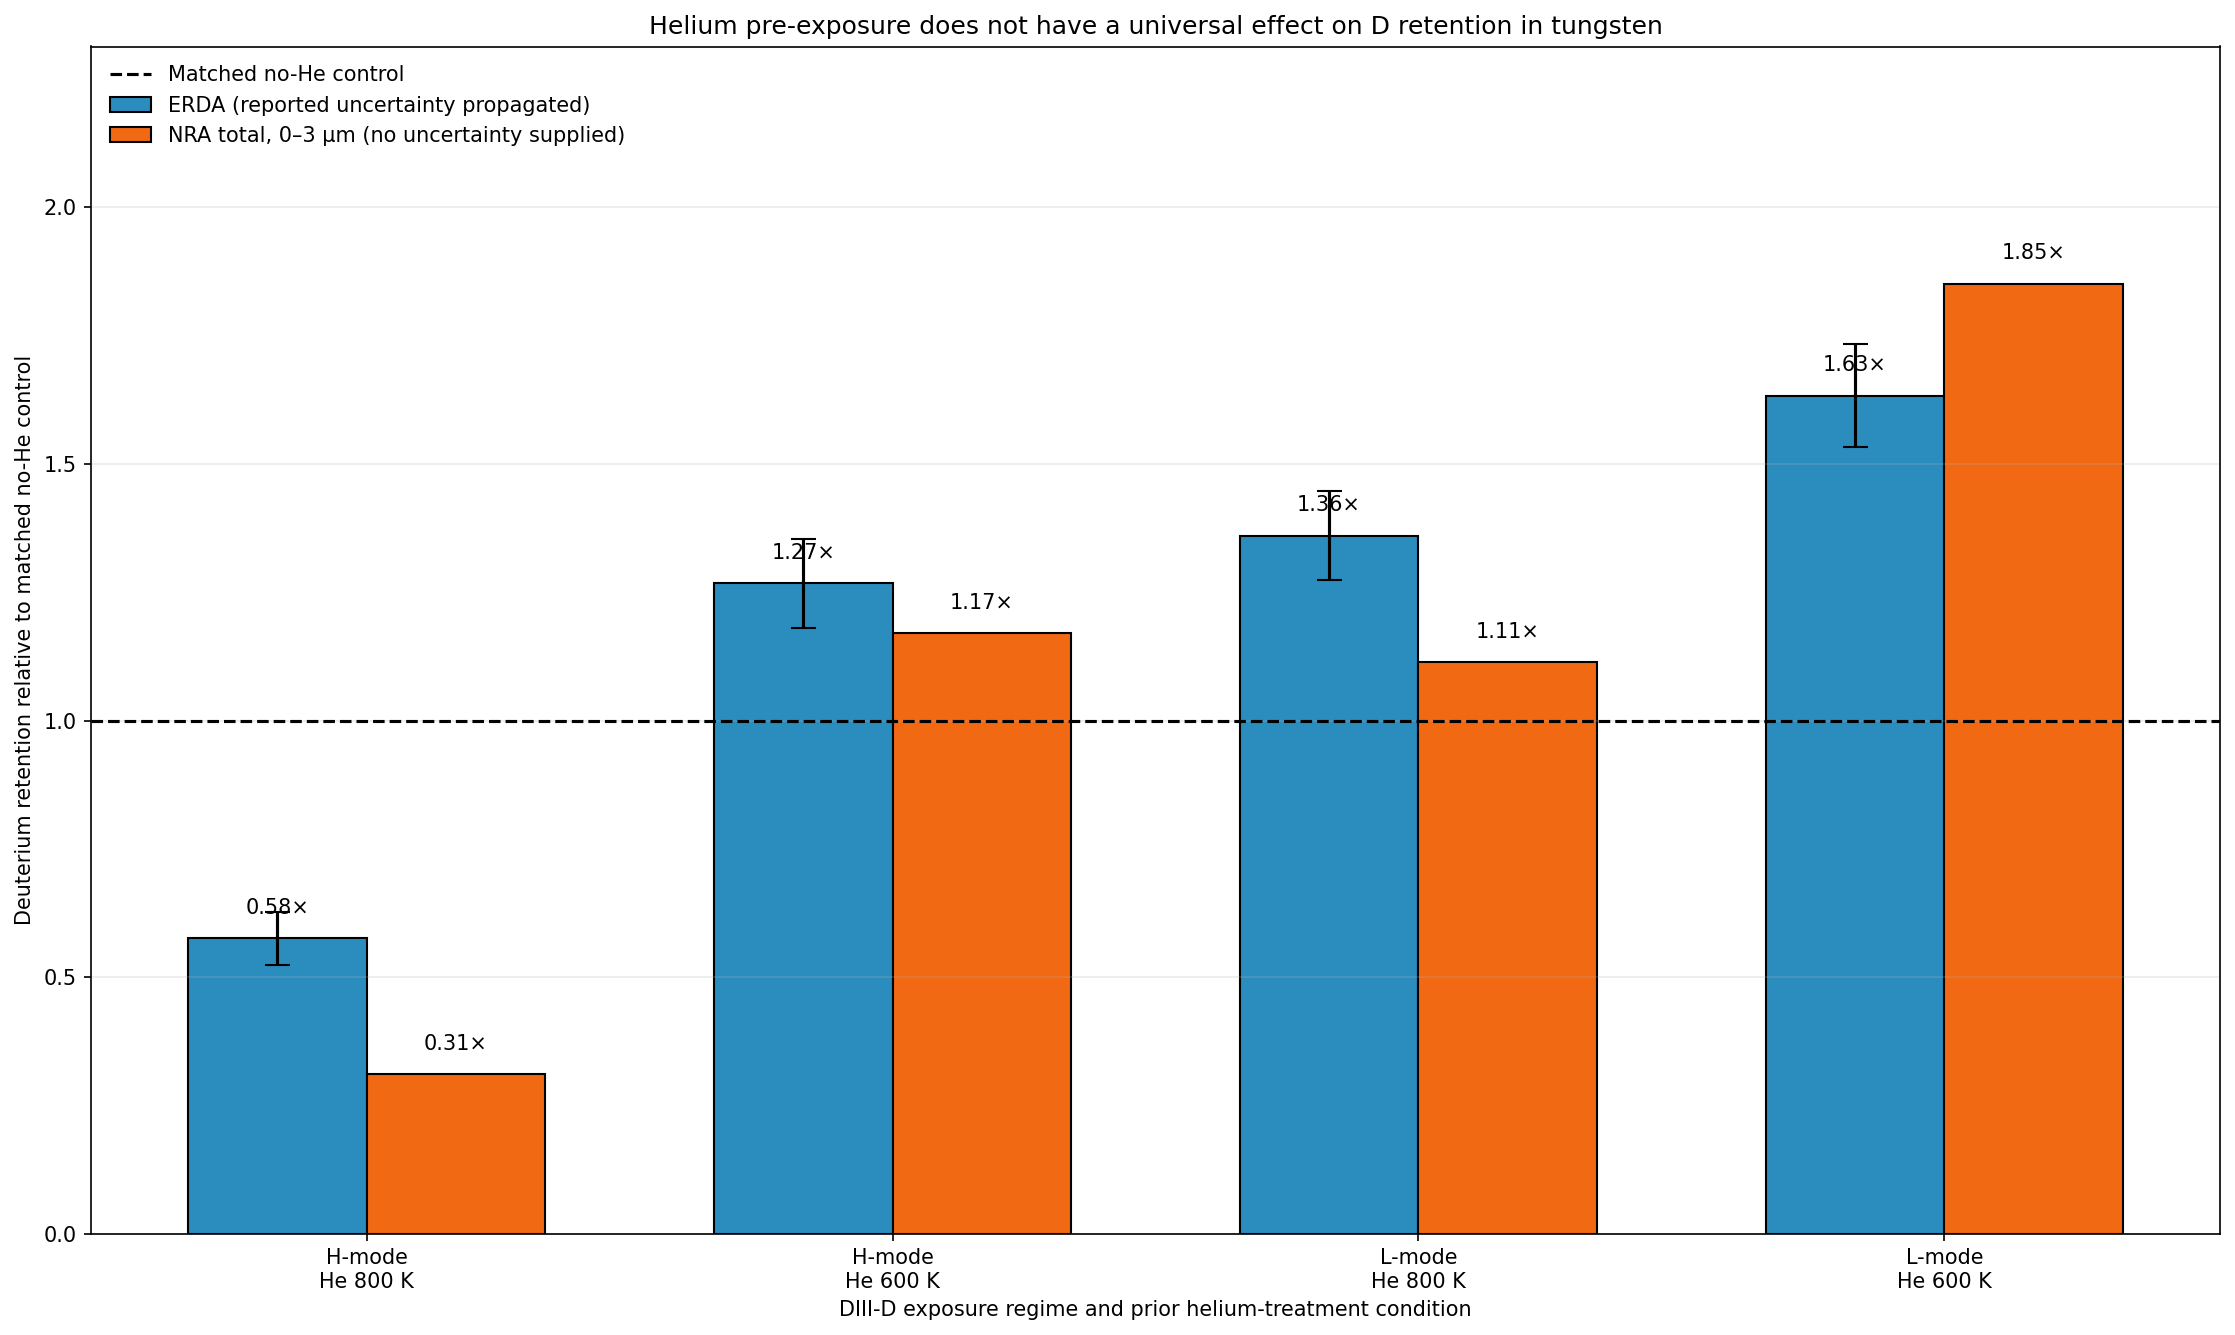

Values in the figure are ratios to the matched no-helium control. The ERDA error bars propagate the reported uncertainties of both the treated coupon and its control; no comparable NRA uncertainties were supplied.

## Helium also changes where the deuterium is retained

The NRA depth bands show that total inventory alone does not capture the full effect:

- **H-mode after 800 K helium treatment** : deuterium decreased throughout the measured region—**68% lower at 0–0.5 µm** and **77% lower at 0.5–3 µm** .
- **H-mode after 600 K helium treatment** : both regions increased—**14% at 0–0.5 µm** and **33% at 0.5–3 µm** .
- **L-mode after 800 K helium treatment** : the near-surface inventory increased **35%** , but the 0.5–3 µm inventory decreased **59%** . The modest 11% total increase therefore reflects a strong redistribution toward the surface.
- **L-mode after 600 K helium treatment** : the near-surface inventory increased **121%** , while the 0.5–3 µm inventory decreased **24%** . Its large total increase was driven by accumulation within the first 0.5 µm.

Thus, under the L-mode conditions, helium increased the measured total while simultaneously inhibiting deeper deuterium penetration.

## Physical interpretation

The attached Baldwin–Doerner study provides a mechanism for the **reduced-inventory** branch of this behavior. Because helium has low solubility in tungsten, implanted helium precipitates into a near-surface nanobubble layer. Their experiments and transport modeling indicate that this layer can:

1. alter deuterium diffusivity and migration energy near the surface;
2. act as a permeation barrier;
3. reduce the deuterium flux penetrating into the tungsten; and
4. promote recycling of hydrogen isotopes back toward the exposed surface.

Their modeling found that nanobubble porosity alone was insufficient to reproduce the barrier; altered transport properties and altered recycling were both needed. That interpretation is consistent with the strong, depth-wide suppression observed here for the 800 K/H-mode coupon and with the shallower redistribution observed under L-mode.

**Literature context** : M.J. Baldwin and R.P. Doerner (2017), *Hydrogen isotope transport across tungsten surfaces exposed to a fusion relevant He ion fluence*, Nuclear Fusion 57 076031, doi:10.1088/1741-4326/aa70b1, especially pp. 2–3 and 9–11.

The paper is mechanistic context from a separate experiment; the numerical comparisons above come from the present FEDER materials delivery.

## Important limitations

- **No replication** : Every experimental cell contains only one tungsten coupon. The ERDA differences are large relative to the reported measurement uncertainties, but those uncertainties do not quantify coupon-to-coupon variability. The results should therefore be treated as strong sample-level observations rather than replicated treatment-effect estimates.
- **The two helium treatments differ in more than temperature** : Both used 70 eV helium, but the 800 K campaign used a fluence of **1.2 × 10²⁵ m⁻²** , flux of **2.83 × 10²² m⁻² s⁻¹** , and duration of **480 s** ; the 600 K campaign used **1.0 × 10²⁵ m⁻²** , **4.1 × 10²¹ m⁻² s⁻¹** , and **4,260 s** . Consequently, their difference cannot be assigned solely to temperature.
- **The subsequent plasma regime matters** : The sign of the 800 K effect reversed between H-mode and L-mode. “Helium-treated tungsten” is therefore not a sufficient description without the subsequent exposure conditions.
- **ERDA and NRA are separate measurements** : They have different depth sensitivities and should not be numerically pooled. Their agreement on the direction of all four total-inventory changes is nevertheless notable.

## Conclusion

**Helium can reduce deuterium retention by creating a near-surface transport/recycling barrier, but that outcome is conditional rather than universal.** In this dataset, the 800 K helium treatment strongly suppressed retention under H-mode, whereas the 600 K treatment enhanced it; under L-mode, both helium treatments increased the total measured inventory while shifting deuterium toward the first 0.5 µm.

### Data files

- [`helium_deuterium_retention_comparison.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_retention_comparison.csv) — matched controls, inventories, uncertainties, ratios, percentage changes, depth-band changes, and helium exposure conditions.
- [`helium_deuterium_retention_raw.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_retention_raw.csv) — raw ERDA and NRA deuterium observations used in the calculation.
- [`helium_deuterium_analysis_summary.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_analysis_summary.json) — machine-readable calculated comparison and chart metadata.
- [`helium_deuterium_measurements.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_measurements.json) — retrieved ERDA, NRA, LAMS, helium-content, and exposure records.
- [`helium_deuterium_discovery.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_discovery.json) — sample catalogue, experimental design, quantity catalogue, and bibliography.
- [`helium_deuterium_literature.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_literature.json) — retrieved literature passages, pages, and catalogue-generated citations.

In [3]:
%%ask
How does the presence of helium affect the retention of deuterium in tungsten?

## 2 — Does the answer depend on the measurement technique?

Three techniques measured retention on these coupons, and they do not all report
the same quantity or carry the same uncertainty.


In [1]:
%%ask
How does the answer depend on the retention measurement technique? Can you 
comment on the uncertainty in these measurements?

I’ll compare the text-based ERDA, NRA, and any profile measurements, then separate reported analytical uncertainty from unmeasured experimental variability.

I’m reading the materials skill to confirm how its measurement methods, units, and evidence boundaries should be interpreted.

Because this skill has recorded learnings, I’m checking them before interpreting missing uncertainties or method disagreements.

The skill confirms that method and unit must remain attached to each value, and one-sample cells prevent uncertainty from representing treatment reproducibility.

I’m listing only the notebook working folder to locate the saved CSV and JSON evidence, without opening any image files.

...

The calculation shows ERDA and NRA agree on all four effect directions, while LAMS is much noisier and conflicts for the 800 K L-mode case.

I’m verifying the generated comparison CSV as text to ensure the reported values and caveat fields were saved correctly.

I’m verifying the uncertainty CSV to preserve the ERDA relative errors and the large LAMS pointwise error ranges behind the conclusions.

The audit found no script edit-and-retry cycle, so no learning update is required; the text outputs contain all quoted calculations.

# Dependence on retention-measurement technique

**Main conclusion** : The answer depends substantially on the measurement technique. **ERDA and NRA agree on the direction of helium’s effect in all four matched comparisons** , but they differ appreciably in effect magnitude. **LAMS is much less decisive** because its pointwise uncertainties are very large, and its L-mode profiles do not reproduce the inventory increases indicated by ERDA and NRA.

## Technique-by-technique comparison

| Plasma regime | Helium pretreatment | ERDA change | NRA change over 0–3 µm | LAMS profile result |
|---|---:|---:|---:|---|
| H-mode | 800 K | −42.4% ± 5.2 percentage points | −68.9% | Profile integral ratio 0.50; 9 of 10 depths lower |
| H-mode | 600 K | +26.7% ± 8.7 percentage points | +17.0% | Profile integral ratio 1.68; 8 of 10 depths higher |
| L-mode | 800 K | +36.1% ± 8.7 percentage points | +11.4% | Profile integral ratio 0.67; only 2 of 10 depths higher |
| L-mode | 600 K | +63.3% ± 10.0 percentage points | +85.1% | Profile integral ratio 0.96; 6 of 10 depths higher |

The ERDA uncertainties in this table were propagated from the reported standard deviations. NRA has no supplied uncertainty, and the LAMS profile-integral ratio is only a within-LAMS summary—not an areal inventory.

## What each technique is actually showing

### ERDA

ERDA reports a single **method-integrated areal concentration** , in atoms cm$^{-2}$. It gives the cleanest numerical separation between the matched coupons:

- Reported relative standard deviations on individual ERDA values are **3.8–7.2%** .
- Relative to the combined reported standard deviations, the matched differences are:
  - **6.2 standard deviations** for the 800 K/H-mode decrease;
  - **3.5 standard deviations** for the 600 K/H-mode increase;
  - **4.9 standard deviations** for the 800 K/L-mode increase;
  - **8.1 standard deviations** for the 600 K/L-mode increase.

These values show that the ERDA differences are large relative to the **supplied ERDA measurement scatter** . They are not treatment-effect significance tests, because there was only one coupon per condition.

### NRA

NRA reports separate areal inventories for two depth bands:

- **Near surface** : 0–0.5 µm.
- **Subsurface** : 0.5–3 µm.

Summing the two bands gives the 0–3 µm result in the table. NRA agrees with ERDA on whether total retention rose or fell, but its depth resolution reveals an important qualification:

| Plasma regime | Helium pretreatment | NRA change at 0–0.5 µm | NRA change at 0.5–3 µm | Interpretation |
|---|---:|---:|---:|---|
| H-mode | 800 K | −67.7% | −76.6% | Suppression throughout both reported bands |
| H-mode | 600 K | +14.4% | +32.6% | Enhancement throughout both bands |
| L-mode | 800 K | +34.5% | −58.9% | More D near the surface but less at depth |
| L-mode | 600 K | +121.0% | −24.4% | Strong near-surface accumulation accompanied by lower deeper inventory |

Thus, the L-mode result depends particularly strongly on depth sensitivity. Saying that helium simply “increases retention” misses the fact that NRA indicates **surface enrichment combined with reduced penetration below 0.5 µm** .

NRA and ERDA should not be treated as interchangeable absolute inventories. Across the matched coupons, the NRA 0–3 µm inventory is **0.98–2.05 times** the ERDA value. That spread is consistent with the methods integrating different depth responses and possibly different sampled regions. It does not by itself show that either method is incorrect.

### LAMS

LAMS provides ten D-concentration points from **0.024 to 2.155 µm** , in **atomic parts per million** , rather than an areal inventory. It therefore cannot be compared directly to ERDA or NRA in absolute units.

As a descriptive comparison, I integrated each APPM-versus-depth profile over its common depth grid and divided the helium-treated profile by its matched control. That summary:

- supports the **800 K/H-mode decrease** ;
- supports the **600 K/H-mode increase** ;
- points in the opposite direction from ERDA/NRA for **800 K/L-mode** ;
- shows almost no net profile difference for **600 K/L-mode** , despite the ERDA/NRA increase.

However, these LAMS discrepancies should not be overinterpreted because the reported pointwise uncertainty is extremely large:

- Median relative standard deviation by sample: **82–103%** .
- Full observed range: **47–199%** .
- Of the 40 matched depth-point comparisons, **none differs by at least two combined reported standard deviations** .
- Only one point differs by at least one combined reported standard deviation.

Consequently, LAMS does not provide a precise independent test of the helium effect in this delivery. It is better viewed as a noisy indication of profile shape than as a quantitative inventory measurement.

## Uncertainty assessment

### ERDA propagated uncertainty

For a helium-to-control ratio $R=H/C$, I propagated the supplied standard deviations as

$$
\sigma_R
=
R\sqrt{
\left(\frac{\sigma_H}{H}\right)^2+
\left(\frac{\sigma_C}{C}\right)^2
}.
$$

The uncertainty in the percentage change $100(R-1)$ is then $100\sigma_R$ percentage points. This calculation assumes that the two reported errors are independent.

Under that assumption, the four ERDA changes are:

| Condition | ERDA effect |
|---|---:|
| 800 K He, H-mode | −42.4% ± 5.2 percentage points |
| 600 K He, H-mode | +26.7% ± 8.7 percentage points |
| 800 K He, L-mode | +36.1% ± 8.7 percentage points |
| 600 K He, L-mode | +63.3% ± 10.0 percentage points |

The sign is robust relative to the supplied ERDA errors in every comparison. Nevertheless, this calculation only propagates the uncertainty field delivered with the ERDA measurements. The accompanying documents do not define a complete calibration or systematic-error budget, so these should not automatically be interpreted as total uncertainties.

### NRA uncertainty

**No NRA standard deviations or other numerical uncertainty estimates were supplied.** Therefore:

- the NRA percentage changes are point estimates;
- their formal significance cannot be calculated;
- NRA’s agreement with ERDA on direction is reassuring, but it is not a statistically quantified validation;
- the blank uncertainty field means **unknown** , not zero.

### LAMS uncertainty

LAMS does include pointwise standard deviations, but they are typically about as large as the measured concentrations. The depth points also come from one profile on one coupon; they are not independent experimental replicates. Integrating them as if they were independent would therefore produce a misleadingly precise error bar.

### Dominant experimental uncertainty: lack of replication

Every pretreatment-by-plasma condition contains **one tungsten coupon** . This is more consequential than the small ERDA error bars:

- Instrument repeatability does not measure coupon-to-coupon variation.
- There is no estimate of between-coupon variance.
- Coupon preparation, local exposure nonuniformity, or spatial sampling could contribute to differences between conditions.
- A measurement can be many reported instrument standard deviations away from its control and still not establish a reproducible treatment effect across tungsten coupons.

Accordingly, the strongest defensible statement is:

> **ERDA and NRA consistently indicate the same direction of helium’s effect for these individual matched coupons, while NRA shows that the L-mode increases are concentrated near the surface. LAMS is too uncertain to provide a comparably strong quantitative conclusion. The absence of replicate coupons prevents converting these sample-level differences into population-level confidence intervals.**

No PNG or other image file was read for this analysis; all calculations came from the saved CSV and JSON records.

## Data files

- [`retention_measurement_technique_comparison.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_measurement_technique_comparison.csv) — matched ERDA, NRA, and LAMS effect summaries, propagated ERDA uncertainty, and cross-method comparisons.
- [`retention_measurement_uncertainty_summary.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_measurement_uncertainty_summary.csv) — per-sample ERDA relative errors, NRA uncertainty availability, and LAMS pointwise relative-error ranges.
- [`retention_measurement_technique_uncertainty_summary.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_measurement_technique_uncertainty_summary.json) — machine-readable method definitions, cross-method findings, and uncertainty boundaries.

## 3 — Retention against the DIII-D plasma condition

The coupons were exposed in two confinement regimes. This asks for the effect of
that difference, in total and with depth, with the method dependence from the
previous question carried through.


I’ll compare matched L- versus H-mode coupons within each helium pretreatment, quantify total and depth-resolved changes, and assess technique-specific uncertainty.

I’m reading the materials skill for the authoritative schema, supported queries, and interpretation rules.

I’m reading the materials skill’s accumulated learnings to apply prior fixes before querying or writing analysis code.

The skill confirms all retention methods must be compared separately, with method, units, depth sensitivity, and one-coupon design limitations preserved.

I’m listing only the working folder to locate prior text outputs and avoid any binary image reads.

...

I’m running the analysis to produce the matched total, NRA depth-band, and LAMS pointwise comparisons plus the required uncertainty-aware chart.

The calculations show L-mode raises ERDA/NRA total retention in every matched stratum, while LAMS gives a weaker and more uncertain technique-dependent picture.

I’m verifying the generated text tables for exact totals, depth-band ratios, and LAMS depth behavior without opening the PNG.

Verification found no calculation mismatches and no edit-and-retry cycle, so no new materials-skill learning entry is required.

# D retention under DIII-D L-mode versus H-mode

**Main result** : Within every matched helium-pretreatment stratum, both **ERDA** and **NRA** measured more total retained deuterium after L-mode exposure than after H-mode exposure. The size of that increase depends strongly on both the pretreatment and the measurement technique:

- **No helium pretreatment** : ERDA and NRA agree closely, each finding an increase of about **27%** from H-mode to L-mode.
- **800 K helium pretreatment** : ERDA finds a **199% increase** , while NRA finds a larger **354% increase** over 0–3 µm.
- **600 K helium pretreatment** : ERDA finds a **63% increase** , while NRA finds a **100% increase** over 0–3 µm.
- **LAMS** gives a less consistent answer. Its depth-profile integral rises by **75%** without helium and **136%** after 800 K helium pretreatment, but is essentially unchanged after 600 K pretreatment. The LAMS pointwise uncertainties are large enough that none of the individual L/H differences reaches one combined reported standard deviation.

Here, percentage change is calculated as

$$
100\left(\frac{D_\mathrm{L-mode}}{D_\mathrm{H-mode}}-1\right).
$$

## Total retained D

ERDA and NRA both report areal concentrations in atoms cm$^{-2}$, although they do not integrate exactly the same depth response. Values below are in $10^{15}$ atoms cm$^{-2}$.

| Helium pretreatment | Technique | H-mode | L-mode | L/H ratio | Change from H- to L-mode |
|---|---|---:|---:|---:|---:|
| None | ERDA | 1.160 ± 0.063 | 1.470 ± 0.071 | 1.27 | +26.7% ± 9.2 percentage points |
| None | NRA, 0–3 µm | 2.098 | 2.657 | 1.27 | +26.6% |
| 800 K | ERDA | 0.668 ± 0.048 | 2.000 ± 0.083 | 2.99 | +199.4% ± 24.8 percentage points |
| 800 K | NRA, 0–3 µm | 0.652 | 2.960 | 4.54 | +354.3% |
| 600 K | ERDA | 1.470 ± 0.062 | 2.400 ± 0.091 | 1.63 | +63.3% ± 9.2 percentage points |
| 600 K | NRA, 0–3 µm | 2.455 | 4.917 | 2.00 | +100.3% |

**Technique agreement** : ERDA and NRA agree on the direction in all three comparisons. Agreement is especially strong without helium pretreatment, where both estimate almost exactly the same relative increase. After helium pretreatment, NRA indicates a larger L-mode/H-mode contrast than ERDA.


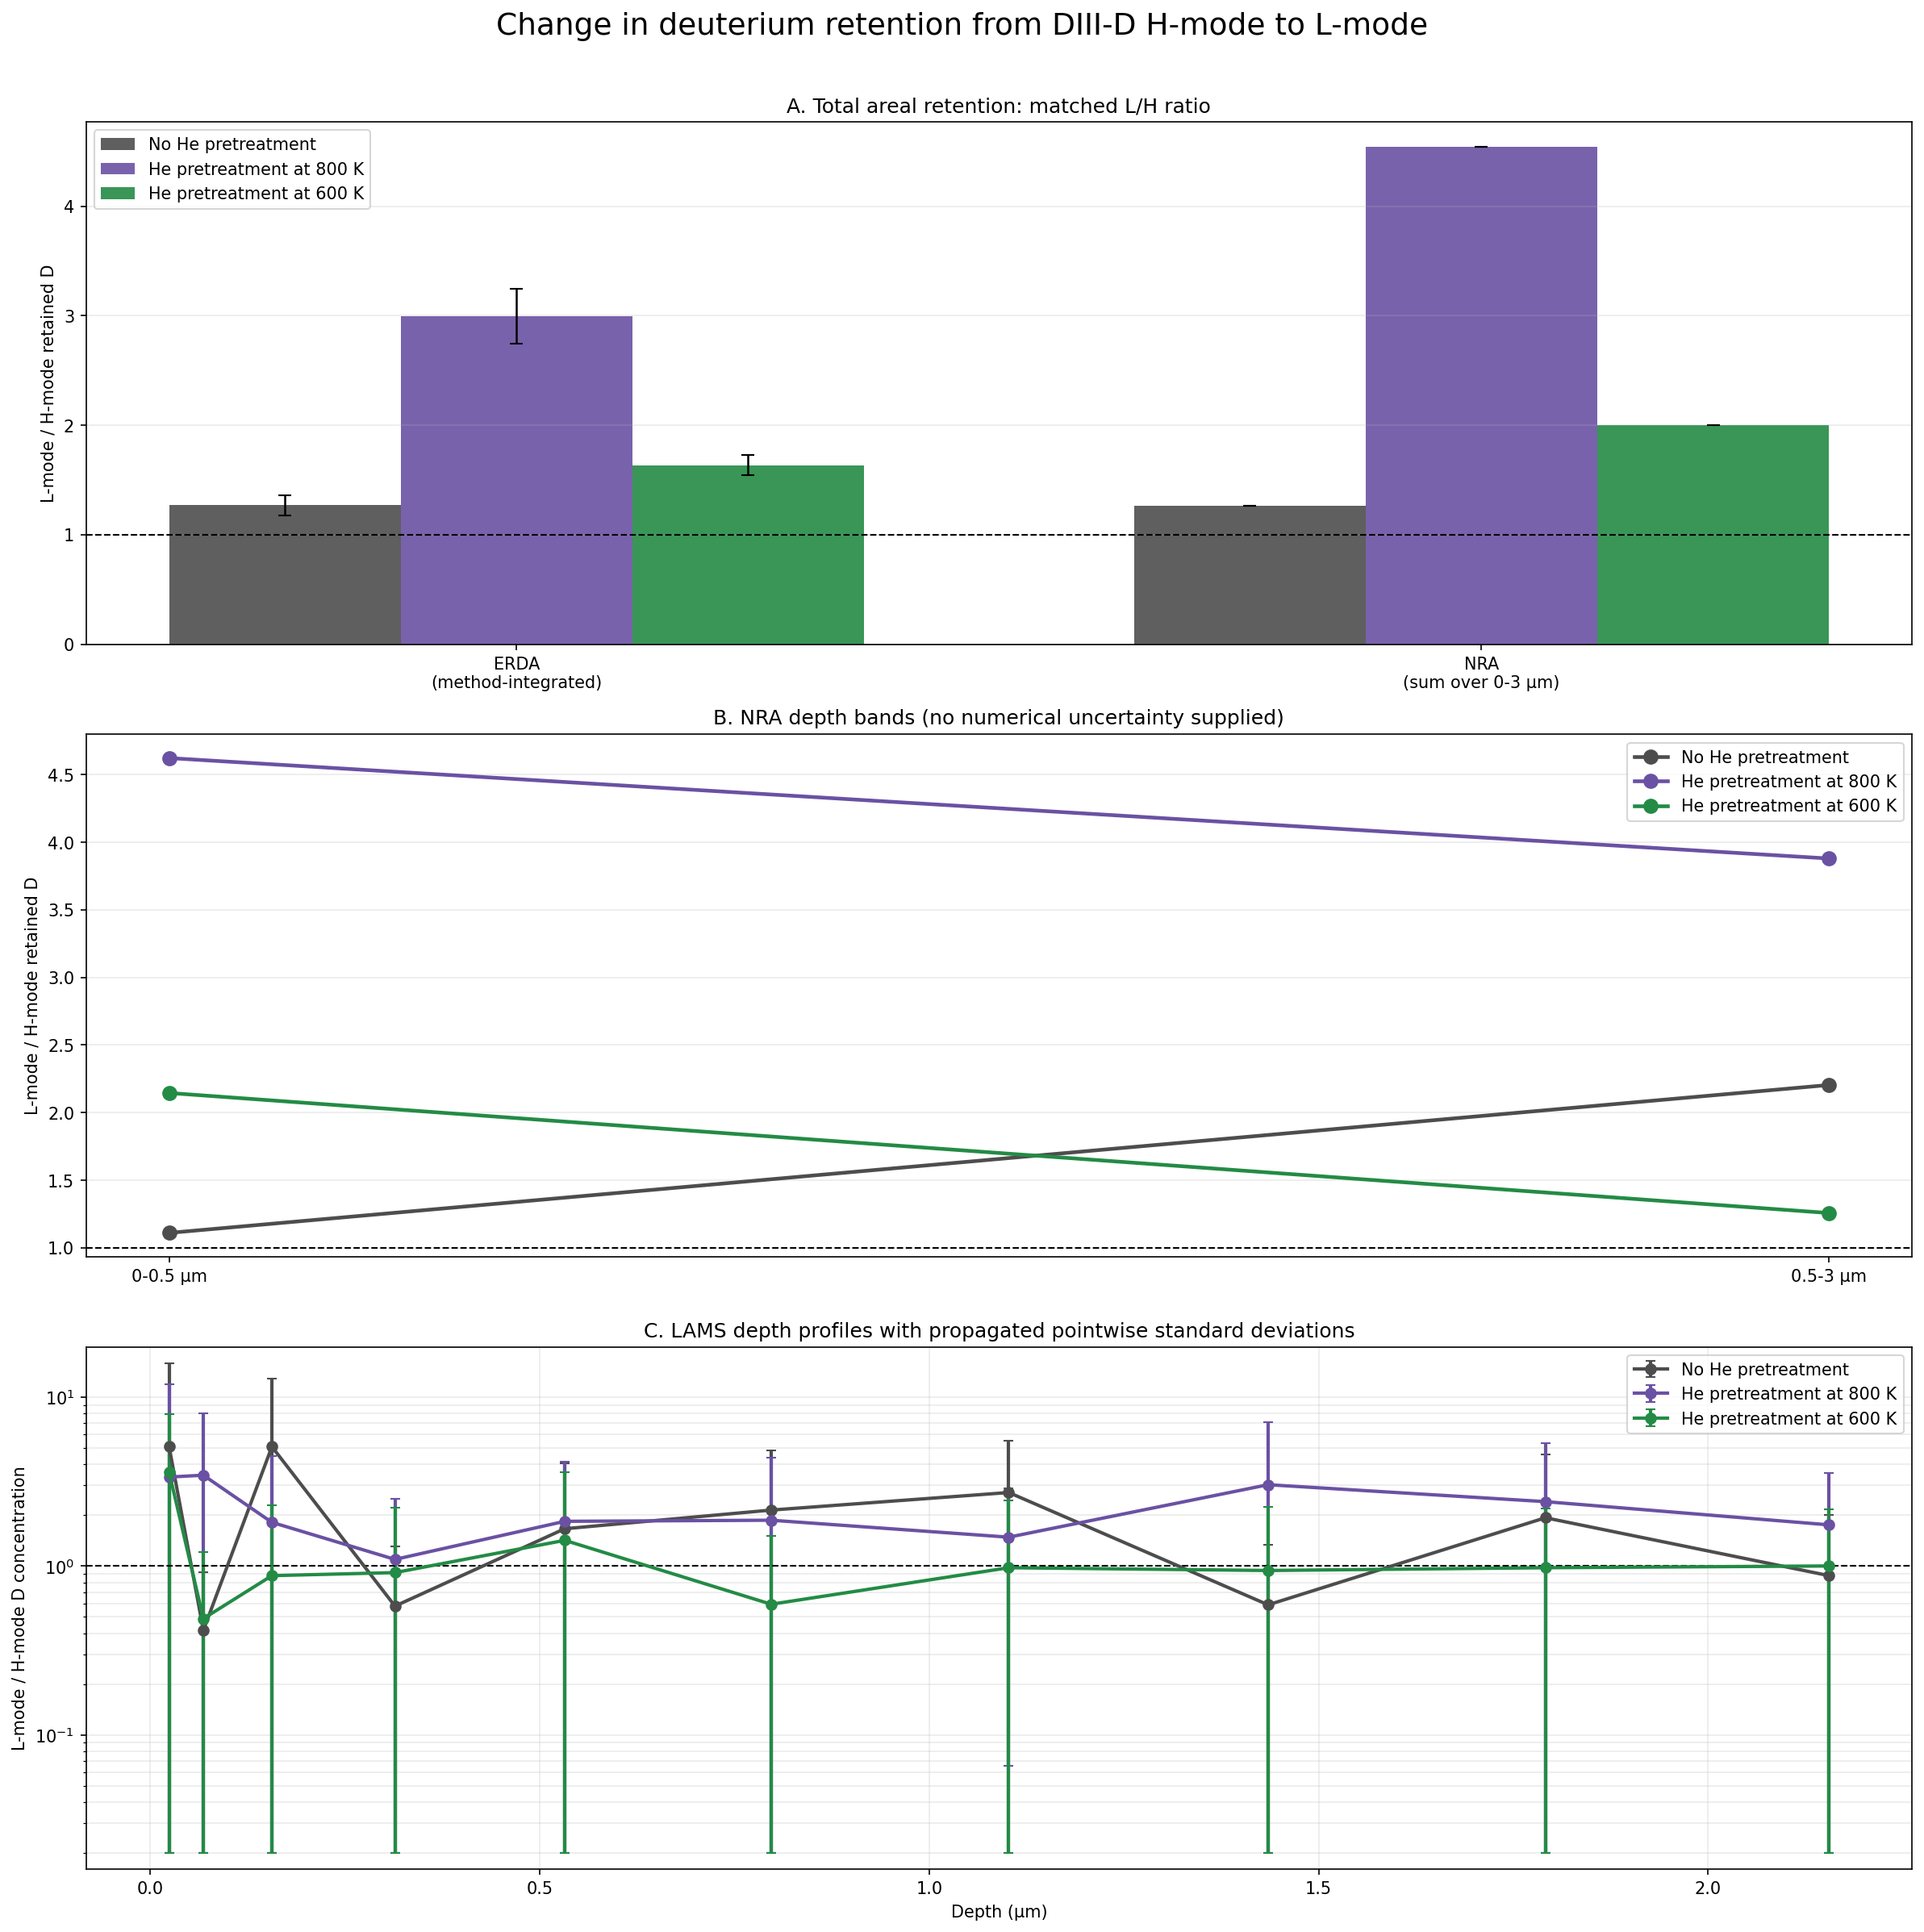

## NRA: depth-resolved retention

NRA divides the retained inventory into two supplied depth bands. Values are again in $10^{15}$ atoms cm$^{-2}$.

| Helium pretreatment | Depth band | H-mode | L-mode | L/H ratio | Change from H- to L-mode |
|---|---:|---:|---:|---:|---:|
| None | 0–0.5 µm | 1.800 | 2.000 | 1.11 | +11.1% |
| None | 0.5–3 µm | 0.298 | 0.657 | 2.20 | +120.5% |
| 800 K | 0–0.5 µm | 0.582 | 2.690 | 4.62 | +362.2% |
| 800 K | 0.5–3 µm | 0.070 | 0.270 | 3.88 | +287.9% |
| 600 K | 0–0.5 µm | 2.060 | 4.420 | 2.15 | +114.6% |
| 600 K | 0.5–3 µm | 0.395 | 0.497 | 1.26 | +25.8% |

These depth bands show that the mode dependence is not spatially uniform:

- **No helium pretreatment** : The near-surface inventory increases only **11%** , while the 0.5–3 µm inventory more than doubles. The L-mode increase therefore extends substantially below 0.5 µm.
- **800 K helium pretreatment** : L-mode raises D retention strongly in both bands. The relative changes are **362% near the surface** and **288% at 0.5–3 µm** . In absolute terms, about **91% of the total NRA increase** comes from the first 0.5 µm.
- **600 K helium pretreatment** : The increase is concentrated near the surface. The 0–0.5 µm inventory rises **115%** , while the 0.5–3 µm inventory rises only **26%** . Approximately **96% of the total NRA increase** comes from the first 0.5 µm.

Thus, the NRA result is more specific than “L-mode retains more D.” Without helium, the strongest relative increase occurs below 0.5 µm; after helium pretreatment, especially at 600 K, the increase is dominated by near-surface retention.

## LAMS: concentration as a function of depth

LAMS reports concentration in APPM at ten depths between 0.024 and 2.155 µm. The table gives the percentage change from H-mode to L-mode at each depth.

| Depth (µm) | No He pretreatment | 800 K He pretreatment | 600 K He pretreatment |
|---:|---:|---:|---:|
| 0.024 | +410.2% | +236.5% | +259.3% |
| 0.068 | −58.4% | +245.1% | −51.2% |
| 0.156 | +409.4% | +81.4% | −12.3% |
| 0.314 | −42.1% | +9.4% | −8.6% |
| 0.532 | +66.3% | +84.0% | +42.0% |
| 0.797 | +114.5% | +86.8% | −40.6% |
| 1.102 | +172.5% | +48.2% | −2.3% |
| 1.435 | −41.1% | +203.2% | −5.9% |
| 1.791 | +93.2% | +140.6% | −2.3% |
| 2.155 | −12.3% | +75.3% | +0.04% |

### Descriptive LAMS profile integrals

A trapezoidal integral of APPM versus depth gives a useful within-LAMS profile summary:

| Helium pretreatment | H-mode profile integral (APPM µm) | L-mode profile integral (APPM µm) | Change |
|---|---:|---:|---:|
| None | 33,415 | 58,365 | +74.7% |
| 800 K | 16,544 | 39,021 | +135.9% |
| 600 K | 56,190 | 56,193 | +0.006% |

These integrals are **not total areal inventories** . APPM µm cannot be converted directly into atoms cm$^{-2}$ without additional density and calibration information, so the LAMS values should not be pooled numerically with ERDA or NRA.

The LAMS profile behavior is:

- **No helium pretreatment** : L-mode is higher at 6 of 10 depths, but the sign alternates with depth.
- **800 K helium pretreatment** : L-mode is higher at all 10 measured depths. This is the most internally consistent LAMS profile result.
- **600 K helium pretreatment** : L-mode is higher at only 3 of 10 depths, and the integrated profile is essentially unchanged. This conflicts with the substantial total-retention increase measured by ERDA and NRA.

## Why the techniques give different answers

### ERDA

ERDA supplies one method-integrated areal concentration per coupon. It produces the clearest and most precise total-retention comparison:

- No He: **+26.7% ± 9.2 percentage points** .
- 800 K He: **+199.4% ± 24.8 percentage points** .
- 600 K He: **+63.3% ± 9.2 percentage points** .

For the ratio $R=L/H$, the propagated reported uncertainty was calculated as

$$
\sigma_R
=
R\sqrt{
\left(\frac{\sigma_L}{L}\right)^2+
\left(\frac{\sigma_H}{H}\right)^2
}.
$$

Relative to the combined supplied standard deviations, the ERDA L/H differences are approximately:

- **3.3 standard deviations** without helium;
- **13.9 standard deviations** after 800 K helium pretreatment;
- **8.5 standard deviations** after 600 K helium pretreatment.

These are measurement-level comparisons, not population-level treatment tests.

### NRA

NRA resolves the inventory into two depth bands and therefore shows where the L/H difference occurs. Its 0–3 µm totals agree directionally with ERDA but give larger mode effects for the helium-pretreated coupons.

However, **no numerical NRA uncertainty was supplied** . The NRA changes are consequently point estimates: their statistical precision cannot be calculated from this delivery, and a blank uncertainty must not be interpreted as zero uncertainty.

### LAMS

LAMS has the finest depth sampling but also the weakest statistical resolution in this dataset:

- None of the **30 matched depth-point comparisons** differs by at least one combined reported standard deviation.
- None differs by two combined standard deviations.
- The largest pointwise difference is only **0.88 combined standard deviations** .
- Many propagated ratio errors are larger than the ratios themselves.

Thus, even changes of several hundred percent in the LAMS table are not individually well resolved because the underlying reported standard deviations are comparably large or larger. The 800 K profile is directionally consistent—L-mode exceeds H-mode at all depths—but its individual points still do not establish statistically resolved depth-specific differences.

## Overall interpretation

**Most defensible conclusion** : ERDA and NRA both indicate that these L-mode-exposed coupons retained more total D than their matched H-mode coupons. The increase ranges from approximately **27% without helium pretreatment** to factors of roughly **3–4.5 after the 800 K helium treatment** , depending on technique.

The depth-resolved answer is more conditional:

1. **No helium pretreatment** : NRA attributes much of the increase to the 0.5–3 µm region, while LAMS gives an oscillatory, highly uncertain profile.
2. **800 K helium pretreatment** : NRA finds a large increase in both depth bands, and LAMS is directionally consistent at all ten depths.
3. **600 K helium pretreatment** : NRA shows a strong near-surface increase, but LAMS indicates essentially no change in its integrated APPM profile. This is the clearest technique-dependent disagreement.

## Experimental limitation

Every L-mode and H-mode experimental cell contains **one tungsten coupon** . Therefore:

- the reported standard deviations describe measurement or analysis scatter, not coupon-to-coupon variability;
- no between-coupon or between-campaign variance can be estimated;
- the comparison bundles the conditions represented by the respective L-mode and H-mode exposure cells—it is not a replicated test of plasma mode alone;
- the results support sample-level differences but not population-level confidence intervals for tungsten generally.

No PNG or other image file was read during this analysis. The figure was generated from the refreshed JSON measurements and verified through its CSV/JSON data sidecars.

## Data files

- [`plasma_mode_retention_source.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/plasma_mode_retention_source.json) — refreshed FEDER measurements, quantity catalogue, sample metadata, exposure records, and experimental design.
- [`plasma_mode_total_retention_comparison.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/plasma_mode_total_retention_comparison.csv) — ERDA and NRA H/L totals, ratios, percentage changes, and available uncertainties.
- [`plasma_mode_nra_depth_comparison.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/plasma_mode_nra_depth_comparison.csv) — NRA values and L/H changes for the 0–0.5 and 0.5–3 µm bands.
- [`plasma_mode_lams_depth_comparison.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/plasma_mode_lams_depth_comparison.csv) — all 30 matched LAMS depth comparisons, propagated pointwise errors, and standardized differences.
- [`plasma_mode_lams_profile_summary.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/plasma_mode_lams_profile_summary.csv) — descriptive LAMS profile integrals and depth-point consistency counts.
- [`plasma_mode_retention_summary.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/plasma_mode_retention_summary.json) — machine-readable summary of the matched comparisons, methods, and design limitation.

In [2]:
%%ask
Quantify changes in D retention with changes in DIII-D plasma conditions 
(L vs. H mode). Include both changes in the total D retention measured 
as well as D retention as a function of depth. As done previously, comment 
on differences in the answer based on the retention measurement technique 
that was used. 

## 4 — What this does not establish

A closing question about the limits of the dataset rather than its contents.


In [3]:
%%ask
What would this analysis NOT be sufficient to claim, and what measurement would 
be needed to go further?

I’ll separate unsupported claims from the additional measurements needed for causal, reproducible, depth-resolved conclusions.

I’m reading the materials skill for its rules on replication, uncertainty, and causal interpretation.

I’m reading the existing materials learnings to apply prior fixes before inspecting or analyzing the saved records.

The skill confirms the main evidentiary boundary: one coupon per cell cannot distinguish plasma-mode effects from coupon or campaign differences.

I’m listing the working directory to locate the prior CSV and JSON sidecars without opening any image files.

...

I’m saving a concise claim-to-evidence table so each proposed next measurement is auditable.

I’m saving the measured H/L exposure contrasts that show why plasma mode is not the only variable changing.

I’m verifying the two text outputs for completeness and formatting; no image files are being opened.

The outputs are complete, and the audit found no script edit-and-retry cycle requiring a learning entry.

# What the current analysis cannot establish

The strongest defensible conclusion is limited to the measured specimens:

> **For these particular tungsten coupons and these two DIII-D exposure campaigns, the L-mode-exposed coupons had higher total D retention by ERDA and NRA than their matched H-mode-exposed coupons.**

The analysis is **not sufficient to establish that changing confinement mode from H to L, by itself, causes the observed increase** . It also cannot establish a universal effect size, a statistically resolved continuous depth profile, or a specific retention mechanism.

## 1. It cannot isolate a causal effect of plasma mode

“L-mode versus H-mode” was not the only experimental variable that changed. The two labels correspond to different groups of DIII-D shots with several different recorded exposure conditions:

| Recorded condition | H-mode campaign | L-mode campaign | L relative to H |
|---|---:|---:|---:|
| Average heat flux | 0.72 MW m$^{-2}$ | 0.47 MW m$^{-2}$ | 35% lower |
| Average particle fluence | $6.7\times10^{22}$ m$^{-2}$ | $7.8\times10^{22}$ m$^{-2}$ | 16% higher |
| Average particle flux | $4.5\times10^{21}$ m$^{-2}$ s$^{-1}$ | $7.5\times10^{21}$ m$^{-2}$ s$^{-1}$ | 67% higher |
| Exposure duration | 12.5 s | 10.0 s | 20% shorter |
| Impact energy | 150 eV | 175 eV | 17% higher |
| Electron density | $5.76\times10^{18}$ m$^{-3}$ | $7.35\times10^{18}$ m$^{-3}$ | 28% higher |
| Electron temperature | 27.9 eV | 40.8 eV | 46% higher |
| DIII-D shots | 5 shots | 4 shots | Different shot sets |

Consequently, the observed retention differences could reflect some combination of:

- confinement regime;
- incident D fluence or flux;
- impact energy;
- sample heating and heat flux;
- exposure duration;
- shot-to-shot plasma history;
- coupon-to-coupon variation; or
- interactions among these variables and the helium pretreatment.

Normalizing retention by the reported fluence would not solve the problem by itself. Retention need not scale linearly with fluence, and flux, energy, temperature, and exposure history also changed.

### Measurement needed to make a causal mode claim

The decisive next step is a **replicated, balanced L/H exposure experiment** , preferably organized as a mode-by-helium factorial design:

1. Use multiple independently prepared tungsten coupons in every L/H-by-helium cell.
2. Randomize or rotate coupon positions to avoid a position–condition correlation.
3. Repeat the comparison across multiple independent DIII-D campaigns or shot days.
4. Measure conditions locally at the coupon:
   - incident D flux and accumulated fluence;
   - heat flux and actual coupon temperature history;
   - incident-ion energy;
   - exposure duration;
   - plasma density and temperature;
   - transient exposure, including ELMs where relevant.
5. Match accumulated D fluence and, as far as physically possible, coupon temperature and impact energy between L- and H-mode conditions.
6. Preselect one calibrated total-retention measurement as the primary endpoint and use the other methods as complementary measurements.

If equalizing those variables is incompatible with producing the two confinement modes, then the result should be framed as a **total effect of the two plasma scenarios** , not a pure confinement-mode effect. Their individual contributions would require enough replicated campaigns to model the measured covariates or a complementary controlled plasma-exposure experiment that varies flux, energy, and temperature independently.

## 2. It cannot generalize the effect sizes to tungsten generally

There is **one coupon per mode-by-pretreatment cell** . For example, the no-helium L/H comparison is one L-mode coupon versus one H-mode coupon; the same is true at each helium pretreatment level.

That means the previously reported increases—approximately 27% without helium, 63–100% after the 600 K helium treatment, and 199–354% after the 800 K treatment, depending on technique—are **differences between individual coupons** , not estimates of the mean effect over a population of tungsten coupons.

The small propagated ERDA errors quantify the supplied measurement-level uncertainty. They do not include:

- coupon-to-coupon variability;
- spatial variation across a coupon;
- preparation-batch variation;
- campaign-to-campaign variation;
- all calibration and systematic uncertainties; or
- uncertainty arising from the plasma-condition mismatch.

Therefore, statements such as “L-mode increases tungsten retention by 200%” or “the effect is statistically significant for tungsten” would go beyond the evidence.

### Measurement needed to generalize

Use **independent coupon replication within each experimental cell** , not merely repeated measurements on the same coupon. Measurements at several positions on each coupon are also useful, but they estimate spatial heterogeneity rather than independent-coupon variability.

The preferred uncertainty structure would separate:

$$
\text{measurement variation}
+
\text{within-coupon spatial variation}
+
\text{between-coupon variation}
+
\text{between-campaign variation}.
$$

A hierarchical analysis could then produce a population-level L/H effect and confidence interval. The number of coupons should be chosen through a power or precision calculation based on pilot estimates of between-coupon and between-campaign variance rather than by treating instrument repeats as independent specimens.

## 3. It cannot establish a complete, technique-independent total D inventory

### ERDA limitation

ERDA provides a method-integrated areal concentration and supplied standard deviations. It supports a precise comparison relative to its reported measurement scatter, but the available record does not establish that its integration covers every depth containing retained D or that its error bars constitute a complete systematic uncertainty budget.

It therefore cannot, on its own, establish the full coupon inventory.

### NRA limitation

NRA provides absolute areal inventories in two broad depth bands, 0–0.5 and 0.5–3 µm. It is the clearest evidence about whether the L/H difference is near-surface or subsurface, but:

- material deeper than 3 µm is outside the reported total;
- the two broad bands cannot resolve a continuous profile or a sharply localized trapping layer;
- no numerical NRA uncertainties were supplied.

The lack of an uncertainty value means **unknown uncertainty** , not zero uncertainty.

### LAMS limitation

LAMS gives ten APPM measurements from 0.024 to 2.155 µm, but the previous analysis found that **none of the 30 matched L/H depth-point differences reached even one combined reported standard deviation** . Its pointwise errors are too large to support statistically resolved differences at particular depths.

Moreover, integrating APPM over depth gives APPM µm, not atoms cm$^{-2}$. Without matrix density, sensitivity, sputter-depth, and absolute concentration calibrations, the LAMS integral is not an independent total-inventory measurement.

### Measurements needed for an absolute depth inventory

A stronger measurement package would include:

1. **Calibrated depth-resolved NRA** with finer depth increments, continuing until the D signal demonstrably reaches background rather than stopping at an assumed depth.
2. Numerical NRA uncertainties, including counting statistics, calibration, stopping-power/depth conversion, background subtraction, and detection limits.
3. **Replicate depth profiles** at multiple positions on each coupon to quantify lateral heterogeneity.
4. Measurements on replicate coupons to quantify specimen variation.
5. A cross-check against an independent total-retention endpoint—such as calibrated temperature-programmed desorption for the total releasable D inventory—while clearly recognizing that releasable D and nuclear-analysis inventory are not necessarily identical physical quantities.
6. ERDA and NRA measurements at the same location where possible, or at documented adjacent representative locations if either method alters the surface.
7. For quantitative LAMS comparison, sputter-depth calibration, tungsten-matrix concentration standards, density conversion, detection limits, and the covariance among depth points.

This would determine whether the technique differences reflect depth sensitivity, calibration, lateral heterogeneity, or genuinely different measured quantities.

## 4. It cannot prove a particular retention mechanism

The existing measurements are post-exposure endpoints. Higher or lower retained inventory and a changed depth distribution do not uniquely identify the process that caused them.

The same endpoint could result from different combinations of:

- incident-D dose;
- implantation depth;
- vacancy or helium-bubble trapping;
- diffusion into or out of the sampled region;
- surface recombination and recycling;
- thermal desorption;
- permeation through the tungsten; or
- erosion or deposition altering the analyzed surface.

For example, near-surface enrichment with less subsurface D is consistent with a transport barrier, but the profile alone does not prove that interpretation.

### Measurements needed to identify mechanism

A mechanistic study should combine the retention profiles with:

- **Temperature-programmed desorption spectroscopy** to measure total released D and resolve release-temperature populations associated with different trapping states.
- **In-situ recycling or permeation measurements** to quantify how much incident D returns to the plasma-facing surface or passes through the sample.
- **Time-resolved incident and released D balance** , rather than only a final post-exposure inventory.
- **Microstructural characterization** , such as transmission electron microscopy or another defect-sensitive method, to measure helium bubbles, cavities, and damaged layers.
- Matched unexposed, D-only, He-only, and He-plus-D controls.
- Replication across coupons and campaigns.

Agreement among depth-resolved NRA, whole-sample desorption, permeation/recycling, and microstructure would provide a much stronger basis for attributing the retention change to trapping or transport rather than merely observing an inventory difference.

## 5. It cannot assign retention to individual shots, ELMs, or plasma phases

Each coupon accumulated exposure over either four or five shots. The final inventory therefore integrates the entire sequence. It cannot reveal:

- which shot contributed most of the retained D;
- whether retention saturated during the sequence;
- whether later shots released D implanted by earlier shots;
- whether ELMs dominated implantation, erosion, or desorption; or
- whether an L–H transition within a shot altered the retained fraction.

### Measurement needed for time- or shot-resolved attribution

Use dedicated coupons for:

- single-shot exposures;
- controlled cumulative shot counts;
- or well-defined within-shot time windows.

Each exposure should be synchronized with local particle-flux, heat-flux, sample-temperature, and transient-event measurements. A sequence of otherwise matched coupons removed after one, two, three, and subsequent shots would distinguish initial uptake, saturation, and loss. If within-shot attribution is required, a time-gated or retractable sample arrangement—or an isotope-labeling strategy combined with post-exposure profiling—would be needed because one endpoint measurement cannot reconstruct the exposure chronology.

# Highest-priority next experiment

If only one next study can be performed, it should be:

> **A replicated, position-balanced L-mode/H-mode DIII-D exposure campaign at matched accumulated D fluence, with local coupon-temperature and incident-particle diagnostics, followed by calibrated depth-resolved NRA with reported uncertainties and an independent whole-sample desorption measurement.**

That experiment would address the three largest current limitations simultaneously:

1. **Replication** would quantify coupon variability.
2. **Matched and measured exposure conditions** would make the mode comparison more nearly causal.
3. **Depth-resolved plus whole-sample measurements** would reconcile the technique-dependent results.

The present data remain valuable as a pilot study: they establish the candidate effect sizes, identify the relevant helium-by-mode interaction, and show where the measurement techniques disagree. They do not yet establish a universal or mode-only causal law.

No PNG or other image file was read in preparing this assessment.

## Data files

- [`retention_claim_limits_and_next_measurements.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_claim_limits_and_next_measurements.csv) — unsupported claims, reasons for each evidentiary limit, and the measurements or experimental designs needed to proceed.
- [`diiid_mode_exposure_confounders.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/diiid_mode_exposure_confounders.csv) — recorded H- and L-mode campaign conditions showing the variables that changed along with confinement mode.